Social Media Engagement Analytics Using Python
Project Overview

This project analyzes a social media engagement dataset containing information such as likes, comments, shares, impressions, watch time, followers, engagement rate, post type, sentiment, country, device type, and other user and content characteristics.

The main objectives of this project are to:

1. Import and understand the dataset using Pandas.

2. Clean and prepare the data for analysis.

3. Perform exploratory data analysis using Pandas and NumPy.

4. Create new features such as engagement score and hashtag count.

5. Perform statistical analysis on important engagement metrics.

6. Visualize social media trends using Matplotlib, Seaborn, and Plotly.

7. Identify patterns related to content performance, users, devices, countries, and sentiment.

8. Generate data-driven insights and recommendations.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display plots inside the notebook
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

# Display more columns when viewing DataFrames
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


Task 1 — Data Import & Setup

The dataset is imported into Python using the Pandas library. After importing the CSV file, the structure and data types of the dataset are examined.

In [3]:
# Task 1 - Import the dataset

import pandas as pd

file_path = "/social_media_engagement_5000.csv"

df = pd.read_csv(file_path)

print("Dataset imported successfully!")
print("Number of rows and columns:", df.shape)

Dataset imported successfully!
Number of rows and columns: (5000, 19)


In [4]:
# View the first 5 rows of the dataset

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [5]:
# View the last 5 rows of the dataset

df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [6]:
# Check the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5000
Number of columns: 19


In [7]:
# Display all column names

print("Column names:")
print(df.columns.tolist())

Column names:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']


In [8]:
# Check dataset information and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [9]:
# Display the data type of every column

df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [10]:
# Check the number of missing values in each column

df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [11]:
# Check whether the dataset contains any missing values

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 900


In [12]:
# Display columns that may contain date/time information

date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

print("Possible date/time columns:")
print(date_columns)

Possible date/time columns:
['watch_time_sec', 'sentiment']


In [14]:
# Find columns related to date or time

date_columns = [
    col for col in df.columns
    if 'date' in col.lower() or 'time' in col.lower()
]

print("Possible date/time columns:")
print(date_columns)

Possible date/time columns:
['watch_time_sec', 'sentiment']


In [15]:
# Check the dataset columns and their data types

print("All columns and their data types:")
print(df.dtypes)

All columns and their data types:
user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [16]:
# Check for columns that contain date-related data

for col in df.columns:
    print(col)

user_id
age
gender
country
post_id
post_type
post_category
likes
comments
shares
watch_time_sec
impression_count
posted_at
follower_count
is_verified
device_type
sentiment
hashtags
engagement_rate


In [17]:
# Convert posted_at column to datetime format

df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')

print("posted_at converted successfully.")
print("Data type:", df['posted_at'].dtype)

posted_at converted successfully.
Data type: datetime64[ns]


/tmp/ipykernel_3200/2370820852.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')


In [18]:
# Final dataset information after data type conversion

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   float64       
 2   gender            4850 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             4850 non-null   float64       
 8   comments          4850 non-null   float64       
 9   shares            4850 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [19]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [20]:
# Calculate the percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': missing_percentage
})

missing_table

,Missing Values,Percentage (%)
user_id,0,0.0
age,150,3.0
gender,150,3.0
country,0,0.0
post_id,0,0.0
post_type,0,0.0
post_category,0,0.0
likes,150,3.0
comments,150,3.0
shares,150,3.0


In [21]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [22]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5000, 19)


In [23]:
# Fill missing numeric values using the median

numeric_missing_columns = [
    'age',
    'likes',
    'comments',
    'shares'
]

for col in numeric_missing_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing numeric values filled using median.")

Missing numeric values filled using median.


In [24]:
# Fill missing categorical values using the mode

categorical_missing_columns = [
    'gender',
    'sentiment'
]

for col in categorical_missing_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing categorical values filled using mode.")

Missing categorical values filled using mode.


In [25]:
# Verify that all missing values have been handled

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values after cleaning:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

Total missing values: 0


In [26]:
# Check gender categories

print("Gender distribution:")
print(df['gender'].value_counts())

print("\nUnique gender values:")
print(df['gender'].unique())

Gender distribution:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Unique gender values:
['Female' 'Male' 'Other']


In [27]:
# Check sentiment categories

print("Sentiment distribution:")
print(df['sentiment'].value_counts())

print("\nUnique sentiment values:")
print(df['sentiment'].unique())

Sentiment distribution:
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

Unique sentiment values:
['negative' 'positive' 'neutral']


In [28]:
# Check post type categories

print("Post type distribution:")
print(df['post_type'].value_counts())

print("\nUnique post types:")
print(df['post_type'].unique())

Post type distribution:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Unique post types:
['image' 'reel' 'text' 'video']


In [29]:
# Check post category distribution

print("Post category distribution:")
print(df['post_category'].value_counts())

print("\nUnique post category values:")
print(df['post_category'].unique())

Post category distribution:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

Unique post category values:
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']


In [30]:
# Check device type categories

print("Device type distribution:")
print(df['device_type'].value_counts())

print("\nUnique device types:")
print(df['device_type'].unique())

Device type distribution:
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64

Unique device types:
['mobile' 'tablet' 'desktop']


In [31]:
# Check for unrealistic negative engagement values

engagement_columns = ['likes', 'comments', 'shares']

for col in engagement_columns:
    print(f"\n{col}:")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Negative values:", (df[col] < 0).sum())


likes:
Minimum: 10.0
Maximum: 19998.0
Negative values: 0

comments:
Minimum: 0.0
Maximum: 2999.0
Negative values: 0

shares:
Minimum: 0.0
Maximum: 1999.0
Negative values: 0


In [32]:
# Check zero values in likes, comments and shares

for col in engagement_columns:
    print(f"{col} - Zero values:", (df[col] == 0).sum())

likes - Zero values: 0
comments - Zero values: 4
shares - Zero values: 1


In [33]:
# Correct unrealistic negative engagement values

for col in engagement_columns:
    df.loc[df[col] < 0, col] = np.nan

# Fill any corrected values using the median
for col in engagement_columns:
    df[col] = df[col].fillna(df[col].median())

print("Unrealistic negative engagement values have been corrected.")

Unrealistic negative engagement values have been corrected.


In [34]:
# Examine the hashtags column

print(df['hashtags'].head(10))

0      #foodie #travel #love
1                   #fitness
2                    #foodie
3        #music #foodie #fun
4                    #travel
5                   #fitness
6                     #music
7    #travel #music #fitness
8       #music #fun #fitness
9           #lifestyle #love
Name: hashtags, dtype: object


In [35]:
# Create a new feature counting the number of hashtags in each post

df['hashtag_count'] = df['hashtags'].str.findall(r'#\w+').str.len()

print("Hashtag count feature created successfully.")
print(df[['hashtags', 'hashtag_count']].head(10))

Hashtag count feature created successfully.
                  hashtags  hashtag_count
0    #foodie #travel #love              3
1                 #fitness              1
2                  #foodie              1
3      #music #foodie #fun              3
4                  #travel              1
5                 #fitness              1
6                   #music              1
7  #travel #music #fitness              3
8     #music #fun #fitness              3
9         #lifestyle #love              2


In [36]:
# Summary of hashtag counts

print("Minimum hashtags:", df['hashtag_count'].min())
print("Maximum hashtags:", df['hashtag_count'].max())
print("Average hashtags:", df['hashtag_count'].mean())

print("\nHashtag count distribution:")
print(df['hashtag_count'].value_counts().sort_index())

Minimum hashtags: 1
Maximum hashtags: 3
Average hashtags: 1.9986

Hashtag count distribution:
hashtag_count
1    1655
2    1697
3    1648
Name: count, dtype: int64


In [37]:
# Standardize sentiment labels

df['sentiment'] = df['sentiment'].str.strip().str.lower()

print("Cleaned sentiment values:")
print(df['sentiment'].unique())

Cleaned sentiment values:
['negative' 'positive' 'neutral']


In [38]:
# Standardize gender labels

df['gender'] = df['gender'].str.strip().str.title()

print("Cleaned gender values:")
print(df['gender'].unique())

Cleaned gender values:
['Female' 'Male' 'Other']


In [39]:
# Check data types after cleaning

print(df.dtypes)

user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
dtype: object


In [40]:
# Final check for missing values after cleaning

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [41]:
# Check the final shape of the cleaned dataset

print("Final dataset shape:", df.shape)

Final dataset shape: (5000, 20)


# Task 3 — Data Exploration Using Pandas

Exploratory data analysis is performed to understand the structure, distribution, and relationships within the cleaned social media engagement dataset. Pandas functions are used to examine the dataset structure, data types, descriptive statistics, categorical distributions, correlations, and grouped summaries.

In [42]:
# Display the first 5 rows of the cleaned dataset

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [43]:
# Display the last 5 rows of the cleaned dataset

df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [44]:
# Check the number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5000
Columns: 20


In [45]:
# Display all column names

print(df.columns.tolist())

['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


In [46]:
# Display complete information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [47]:
# Display data types of all columns

df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [48]:
# Generate descriptive statistics for numeric columns

df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [49]:
# Generate descriptive statistics for all columns

df.describe(include='all')

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000,5000,5000.000000,5000,5000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000
unique,NaN,NaN,3,10,NaN,4,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,3,761,NaN,NaN
top,NaN,NaN,Male,India,NaN,reel,fitness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,mobile,positive,#tech,NaN,NaN
freq,NaN,NaN,1849,535,NaN,1283,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4517,1684,2513,201,NaN,NaN
mean,54561.890800,38.440400,NaN,NaN,548042.909000,NaN,NaN,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,NaN,NaN,NaN,NaN,0.964356,1.998600
min,10055.000000,13.000000,NaN,NaN,100068.000000,NaN,NaN,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,NaN,NaN,NaN,NaN,0.006363,1.000000
25%,32309.500000,26.000000,NaN,NaN,322543.500000,NaN,NaN,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,NaN,NaN,NaN,NaN,0.145781,1.000000
50%,54374.500000,38.000000,NaN,NaN,548077.500000,NaN,NaN,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,NaN,NaN,NaN,NaN,0.253896,2.000000
75%,77180.500000,51.000000,NaN,NaN,771574.500000,NaN,NaN,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,NaN,NaN,NaN,NaN,0.504794,3.000000
max,99963.000000,64.000000,NaN,NaN,999455.000000,NaN,NaN,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,NaN,NaN,NaN,NaN,191.504348,3.000000


In [50]:
# Analyze gender distribution

print("Gender distribution:")
print(df['gender'].value_counts())

print("\nPercentage distribution:")
print(df['gender'].value_counts(normalize=True) * 100)

Gender distribution:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Percentage distribution:
gender
Male      36.98
Other     31.62
Female    31.40
Name: proportion, dtype: float64


In [51]:
# Analyze post type distribution

print("Post type distribution:")
print(df['post_type'].value_counts())

print("\nPercentage distribution:")
print(df['post_type'].value_counts(normalize=True) * 100)

Post type distribution:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Percentage distribution:
post_type
reel     25.66
image    24.94
text     24.90
video    24.50
Name: proportion, dtype: float64


In [52]:
# Analyze post category distribution

print("Post category distribution:")
print(df['post_category'].value_counts())

print("\nPercentage distribution:")
print(df['post_category'].value_counts(normalize=True) * 100)

Post category distribution:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

Percentage distribution:
post_category
fitness      13.50
tech         13.30
music        12.70
education    12.62
lifestyle    12.14
travel       12.00
fashion      11.88
food         11.86
Name: proportion, dtype: float64


In [53]:
# Analyze country distribution

print("Country distribution:")
print(df['country'].value_counts())

print("\nNumber of unique countries:", df['country'].nunique())

Country distribution:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Number of unique countries: 10


In [54]:
# Analyze sentiment distribution

print("Sentiment distribution:")
print(df['sentiment'].value_counts())

print("\nPercentage distribution:")
print(df['sentiment'].value_counts(normalize=True) * 100)

Sentiment distribution:
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

Percentage distribution:
sentiment
positive    50.26
neutral     30.54
negative    19.20
Name: proportion, dtype: float64


In [55]:
# Analyze device type distribution

print("Device type distribution:")
print(df['device_type'].value_counts())

print("\nNumber of unique devices:", df['device_type'].nunique())

Device type distribution:
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64

Number of unique devices: 3


In [56]:
# Examine unique values and number of unique values

categorical_columns = [
    'gender',
    'country',
    'post_type',
    'post_category',
    'device_type',
    'sentiment'
]

for col in categorical_columns:
    print("\n" + "=" * 50)
    print("Column:", col)
    print("Number of unique values:", df[col].nunique())
    print("Unique values:", df[col].unique())


Column: gender
Number of unique values: 3
Unique values: ['Female' 'Male' 'Other']

Column: country
Number of unique values: 10
Unique values: ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']

Column: post_type
Number of unique values: 4
Unique values: ['image' 'reel' 'text' 'video']

Column: post_category
Number of unique values: 8
Unique values: ['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

Column: device_type
Number of unique values: 3
Unique values: ['mobile' 'tablet' 'desktop']

Column: sentiment
Number of unique values: 3
Unique values: ['negative' 'positive' 'neutral']


In [57]:
# Create correlation matrix for numeric variables

correlation_matrix = df.select_dtypes(include=np.number).corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


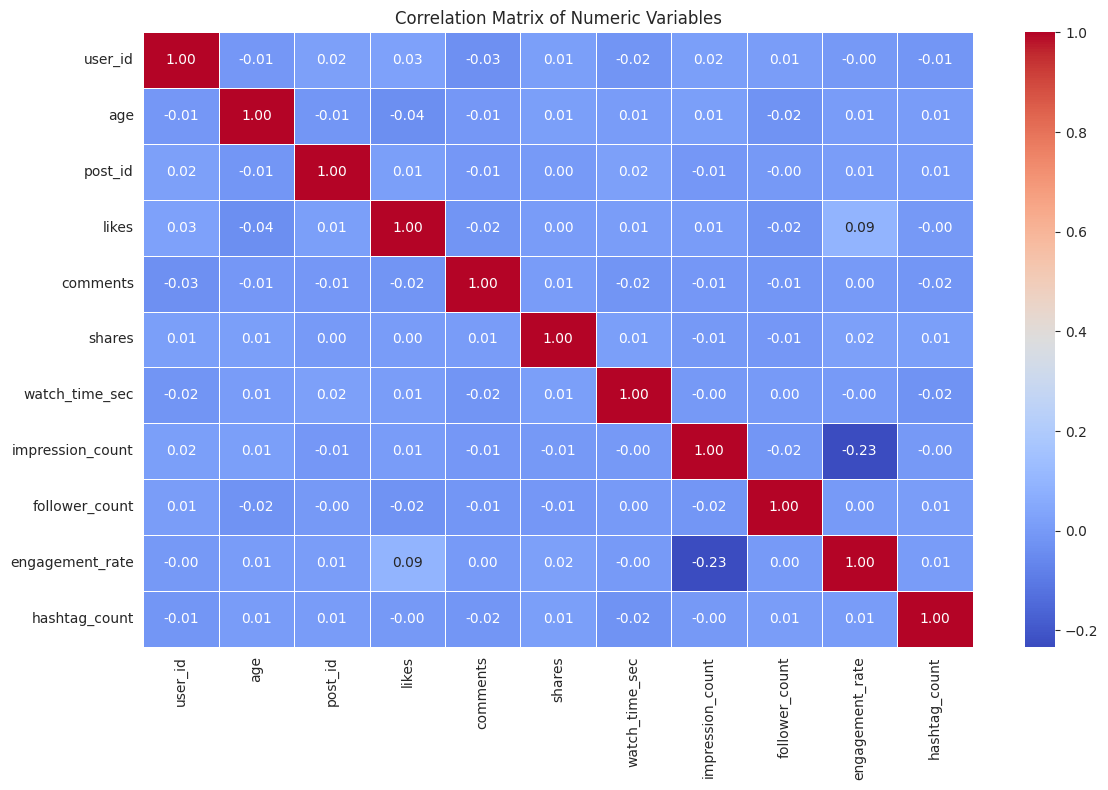

In [58]:
# Visualize the correlation matrix using a heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

In [59]:
# Calculate average likes by post type

avg_likes_post_type = (
    df.groupby('post_type')['likes']
    .mean()
    .sort_values(ascending=False)
)

print("Average likes by post type:")
print(avg_likes_post_type)

Average likes by post type:
post_type
video    10188.600000
image    10104.865277
text     10100.148193
reel     10037.802416
Name: likes, dtype: float64


In [60]:
# Calculate average engagement rate by post type

avg_engagement_post_type = (
    df.groupby('post_type')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
)

print("Average engagement rate by post type:")
print(avg_engagement_post_type)

Average engagement rate by post type:
post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64


In [61]:
# Calculate total impressions and average engagement rate by country

country_summary = (
    df.groupby('country')
    .agg(
        total_impressions=('impression_count', 'sum'),
        average_impressions=('impression_count', 'mean'),
        average_engagement_rate=('engagement_rate', 'mean'),
        average_likes=('likes', 'mean')
    )
    .sort_values('average_engagement_rate', ascending=False)
)

country_summary

,total_impressions,average_impressions,average_engagement_rate,average_likes
country,,,,
Brazil,24793360,49193.174603,1.540704,9886.689484
Australia,23834767,48346.383367,1.324339,10294.124746
France,25656926,51727.673387,1.146402,10372.876008
UAE,24610992,48928.413519,1.112352,10227.487078
Canada,24984716,48703.150097,0.916659,10063.066277
UK,25201861,51119.393509,0.850966,9935.650101
Japan,23418816,49616.135593,0.769623,10088.862288
Germany,23816649,48605.406122,0.759000,10130.458163
India,28067377,52462.386916,0.655005,9962.468224


In [62]:
# Analyze engagement metrics by sentiment

sentiment_summary = (
    df.groupby('sentiment')
    .agg(
        posts=('post_id', 'count'),
        average_likes=('likes', 'mean'),
        average_comments=('comments', 'mean'),
        average_shares=('shares', 'mean'),
        average_engagement_rate=('engagement_rate', 'mean'),
        average_watch_time=('watch_time_sec', 'mean')
    )
    .sort_values('average_engagement_rate', ascending=False)
)

sentiment_summary

,posts,average_likes,average_comments,average_shares,average_engagement_rate,average_watch_time
sentiment,,,,,,
negative,960,10208.096875,1516.094792,1007.307292,1.038486,4054.639583
neutral,1527,9923.194499,1528.404060,996.565160,0.991170,4031.823183
positive,2513,10180.062077,1480.650617,1005.086749,0.919744,3988.646240


In [63]:
# Analyze performance by content category

category_summary = (
    df.groupby('post_category')
    .agg(
        posts=('post_id', 'count'),
        average_likes=('likes', 'mean'),
        average_comments=('comments', 'mean'),
        average_shares=('shares', 'mean'),
        average_engagement_rate=('engagement_rate', 'mean'),
        average_impressions=('impression_count', 'mean')
    )
    .sort_values('average_engagement_rate', ascending=False)
)

category_summary

,posts,average_likes,average_comments,average_shares,average_engagement_rate,average_impressions
post_category,,,,,,
food,593,10225.522766,1510.876897,1002.801012,1.358628,50966.573356
tech,665,10171.571429,1505.548872,1009.369925,1.160475,50692.517293
lifestyle,607,10180.559308,1467.840198,991.140033,1.091019,50334.296540
music,635,10205.749606,1558.710236,1024.089764,0.888803,49785.692913
fitness,675,9914.602222,1501.142222,1042.047407,0.865628,49150.431111
education,631,10126.487322,1455.337559,996.445325,0.844222,49232.115689
fashion,594,9843.356902,1530.540404,982.523569,0.807109,50082.023569
travel,600,10196.304167,1485.948333,968.306667,0.702223,49962.335000


In [64]:
# Compare performance of verified and non-verified accounts

verified_summary = (
    df.groupby('is_verified')
    .agg(
        posts=('post_id', 'count'),
        average_likes=('likes', 'mean'),
        average_comments=('comments', 'mean'),
        average_shares=('shares', 'mean'),
        average_engagement_rate=('engagement_rate', 'mean'),
        average_watch_time=('watch_time_sec', 'mean'),
        average_impressions=('impression_count', 'mean')
    )
)

verified_summary

,posts,average_likes,average_comments,average_shares,average_engagement_rate,average_watch_time,average_impressions
is_verified,,,,,,,
False,4517,10137.201129,1505.511401,1001.599292,0.954744,4005.201240,49935.288244
True,483,9824.533126,1469.573499,1015.173913,1.054250,4101.494824,50747.343685


In [65]:
# Analyze watch time by device type

device_summary = (
    df.groupby('device_type')
    .agg(
        posts=('post_id', 'count'),
        average_watch_time=('watch_time_sec', 'mean'),
        average_engagement_rate=('engagement_rate', 'mean'),
        average_impressions=('impression_count', 'mean')
    )
    .sort_values('average_watch_time', ascending=False)
)

device_summary

,posts,average_watch_time,average_engagement_rate,average_impressions
device_type,,,,
mobile,1684,4087.830760,1.123999,49516.948931
tablet,1658,3979.736429,0.804560,49597.971049
desktop,1658,3974.792521,0.962006,50934.068758


# Task 4 — Data Wrangling

Data wrangling involves transforming the cleaned dataset into a more useful structure for analysis. New analytical features are created, including an engagement score and log-transformed engagement metrics. Additional time-based features are extracted from the posted_at column. Grouped summaries are also generated to compare social media performance across different dimensions.

In [66]:
# Create an engagement score

df['engagement_score'] = (
    df['likes'] +
    (2 * df['comments']) +
    (3 * df['shares'])
)

print("Engagement score created successfully.")
print(df[['likes', 'comments', 'shares', 'engagement_score']].head())

Engagement score created successfully.
     likes  comments  shares  engagement_score
0   7011.0     354.0  1157.0           11190.0
1  11750.0    2606.0  1807.0           22383.0
2   4862.0     344.0   955.0            8415.0
3   5350.0    1083.0  1049.0           10663.0
4  12682.0    2735.0  1300.0           22052.0


In [67]:
# Summary statistics for engagement score

print("Engagement score statistics:")
print(df['engagement_score'].describe())

Engagement score statistics:
count     5000.000000
mean     16119.808800
std       6176.641492
min        264.000000
25%      11354.750000
50%      16011.000000
75%      20974.500000
max      31345.000000
Name: engagement_score, dtype: float64


In [68]:
# Create log-transformed engagement metrics

df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_shares'] = np.log1p(df['shares'])
df['log_impressions'] = np.log1p(df['impression_count'])
df['log_followers'] = np.log1p(df['follower_count'])

print("Log-transformed metrics created successfully.")
df[['log_likes', 'log_comments', 'log_shares',
    'log_impressions', 'log_followers']].head()

Log-transformed metrics created successfully.


,log_likes,log_comments,log_shares,log_impressions,log_followers
0,8.855378,5.872118,7.054450,10.706632,11.311238
1,9.371694,7.865955,7.499977,11.292491,8.693497
2,8.489411,5.843544,6.862758,10.711280,13.125925
3,8.585039,6.988413,6.956545,11.162744,13.081985
4,9.448018,7.914252,7.170888,8.702843,12.858234


In [69]:
# Extract useful time-based features from posted_at

df['post_date'] = df['posted_at'].dt.date
df['post_year'] = df['posted_at'].dt.year
df['post_month'] = df['posted_at'].dt.month
df['post_day'] = df['posted_at'].dt.day
df['post_hour'] = df['posted_at'].dt.hour
df['day_of_week'] = df['posted_at'].dt.day_name()

print("Time-based features created successfully.")

df[['posted_at', 'post_date', 'post_year', 'post_month',
    'post_hour', 'day_of_week']].head()

Time-based features created successfully.


,posted_at,post_date,post_year,post_month,post_hour,day_of_week
0,2022-12-17,2022-12-17,2022,12,0,Saturday
1,2023-06-02,2023-06-02,2023,6,0,Friday
2,2023-05-07,2023-05-07,2023,5,0,Sunday
3,2023-02-12,2023-02-12,2023,2,0,Sunday
4,2023-05-23,2023-05-23,2023,5,0,Tuesday


In [70]:
# Create time-of-day categories

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['post_hour'].apply(get_time_of_day)

print("Time-of-day feature created successfully.")
print(df['time_of_day'].value_counts())

Time-of-day feature created successfully.
time_of_day
Night    5000
Name: count, dtype: int64


In [71]:
# Grouped summary by post type

post_type_summary = (
    df.groupby('post_type')
    .agg(
        posts=('post_id', 'count'),
        avg_likes=('likes', 'mean'),
        avg_comments=('comments', 'mean'),
        avg_shares=('shares', 'mean'),
        avg_engagement_score=('engagement_score', 'mean'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        avg_impressions=('impression_count', 'mean'),
        avg_watch_time=('watch_time_sec', 'mean')
    )
    .sort_values('avg_engagement_rate', ascending=False)
)

post_type_summary

,posts,avg_likes,avg_comments,avg_shares,avg_engagement_score,avg_engagement_rate,avg_impressions,avg_watch_time
post_type,,,,,,,,
video,1225,10188.600000,1479.160000,996.834286,16137.422857,1.122365,49862.014694,4026.673469
text,1245,10100.148193,1499.106024,1013.989558,16140.328916,1.064549,49987.218474,4010.873092
image,1247,10104.865277,1525.235766,1019.289495,16213.205293,0.895646,49727.421812,3881.448276
reel,1283,10037.802416,1504.187062,982.042089,15992.302806,0.783047,50462.598597,4135.727202


In [72]:
# Grouped summary by country

country_summary = (
    df.groupby('country')
    .agg(
        posts=('post_id', 'count'),
        avg_likes=('likes', 'mean'),
        avg_comments=('comments', 'mean'),
        avg_shares=('shares', 'mean'),
        avg_engagement_score=('engagement_score', 'mean'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        avg_impressions=('impression_count', 'mean'),
        avg_watch_time=('watch_time_sec', 'mean')
    )
    .sort_values('avg_engagement_rate', ascending=False)
)

country_summary

,posts,avg_likes,avg_comments,avg_shares,avg_engagement_score,avg_engagement_rate,avg_impressions,avg_watch_time
country,,,,,,,,
Brazil,504,9886.689484,1490.434524,1008.859127,15894.135913,1.540704,49193.174603,4049.206349
Australia,493,10294.124746,1485.803245,1029.693712,16354.812373,1.324339,48346.383367,4150.675456
France,496,10372.876008,1478.695565,1051.812500,16485.704637,1.146402,51727.673387,3992.747984
UAE,503,10227.487078,1541.214712,989.075547,16277.143141,1.112352,48928.413519,4007.823062
Canada,513,10063.066277,1546.582846,996.245614,16144.968811,0.916659,48703.150097,4003.695906
UK,493,9935.650101,1463.042596,985.681542,15818.779919,0.850966,51119.393509,4118.693712
Japan,472,10088.862288,1530.434322,959.351695,16027.786017,0.769623,49616.135593,3878.387712
Germany,490,10130.458163,1531.826531,973.379592,16114.250000,0.759000,48605.406122,3976.377551
India,535,9962.468224,1494.917757,1035.315888,16058.251402,0.655005,52462.386916,4016.835514


In [73]:
# Grouped summary by sentiment

sentiment_summary = (
    df.groupby('sentiment')
    .agg(
        posts=('post_id', 'count'),
        avg_likes=('likes', 'mean'),
        avg_comments=('comments', 'mean'),
        avg_shares=('shares', 'mean'),
        avg_engagement_score=('engagement_score', 'mean'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        avg_impressions=('impression_count', 'mean'),
        avg_watch_time=('watch_time_sec', 'mean')
    )
    .sort_values('avg_engagement_rate', ascending=False)
)

sentiment_summary

,posts,avg_likes,avg_comments,avg_shares,avg_engagement_score,avg_engagement_rate,avg_impressions,avg_watch_time
sentiment,,,,,,,,
negative,960,10208.096875,1516.094792,1007.307292,16262.208333,1.038486,50191.960417,4054.639583
neutral,1527,9923.194499,1528.404060,996.565160,15969.698101,0.991170,49515.971185,4031.823183
positive,2513,10180.062077,1480.650617,1005.086749,16156.623558,0.919744,50248.107441,3988.646240


In [74]:
# Analyze performance by time of day

time_summary = (
    df.groupby('time_of_day')
    .agg(
        posts=('post_id', 'count'),
        avg_impressions=('impression_count', 'mean'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        avg_likes=('likes', 'mean'),
        avg_watch_time=('watch_time_sec', 'mean')
    )
    .sort_values('avg_impressions', ascending=False)
)

time_summary

,posts,avg_impressions,avg_engagement_rate,avg_likes,avg_watch_time
time_of_day,,,,,
Night,5000,50013.7328,0.964356,10106.9974,4014.5032


In [75]:
# Check the final columns after data wrangling

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Number of rows: 5000
Number of columns: 33

Columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count', 'engagement_score', 'log_likes', 'log_comments', 'log_shares', 'log_impressions', 'log_followers', 'post_date', 'post_year', 'post_month', 'post_day', 'post_hour', 'day_of_week', 'time_of_day']


In [76]:
# Demonstrate Pandas concat using grouped summaries

post_type_part = (
    df.groupby('post_type')['engagement_rate']
    .mean()
    .reset_index(name='avg_engagement_rate')
)

sentiment_part = (
    df.groupby('sentiment')['engagement_rate']
    .mean()
    .reset_index(name='avg_engagement_rate')
)

combined_summary = pd.concat(
    [
        post_type_part.assign(summary_type='Post Type'),
        sentiment_part.assign(summary_type='Sentiment')
    ],
    ignore_index=True
)

combined_summary

,post_type,avg_engagement_rate,summary_type,sentiment
0,image,0.895646,Post Type,NaN
1,reel,0.783047,Post Type,NaN
2,text,1.064549,Post Type,NaN
3,video,1.122365,Post Type,NaN
4,NaN,1.038486,Sentiment,negative
5,NaN,0.991170,Sentiment,neutral
6,NaN,0.919744,Sentiment,positive


# Task 5 — Statistical Analysis

Descriptive statistical analysis is performed on the major social media engagement metrics. Mean, median, mode, standard deviation, variance, percentiles, skewness, and kurtosis are calculated to understand the central tendency, variability, and distribution of the data.

In [77]:
# Select the metrics required for statistical analysis

stat_columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

print("Metrics selected for statistical analysis:")
print(stat_columns)

Metrics selected for statistical analysis:
['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']


In [78]:
# Calculate mean, median, and mode

stat_summary = pd.DataFrame(index=stat_columns)

stat_summary['Mean'] = df[stat_columns].mean()
stat_summary['Median'] = df[stat_columns].median()
stat_summary['Mode'] = df[stat_columns].mode().iloc[0]

stat_summary

,Mean,Median,Mode
likes,10106.997400,10105.500000,10105.500000
comments,1502.039800,1497.000000,1497.000000
shares,1002.910600,1012.000000,1012.000000
watch_time_sec,4014.503200,4034.500000,916.000000
engagement_rate,0.964356,0.253896,0.006363
follower_count,393698.224800,388982.000000,497502.000000


In [79]:
# Calculate standard deviation and variance

stat_summary['Standard Deviation'] = df[stat_columns].std()
stat_summary['Variance'] = df[stat_columns].var()

stat_summary

,Mean,Median,Mode,Standard Deviation,Variance
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10


In [80]:
# Calculate important percentiles

percentiles = df[stat_columns].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95]
)

percentiles.index = [
    '25th Percentile',
    '50th Percentile',
    '75th Percentile',
    '90th Percentile',
    '95th Percentile'
]

percentiles

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
25th Percentile,5235.00,792.00,511.00,2017.75,0.145781,194480.00
50th Percentile,10105.50,1497.00,1012.00,4034.50,0.253896,388982.00
75th Percentile,14959.00,2235.25,1483.00,6020.25,0.504794,589744.25
90th Percentile,18016.30,2695.10,1795.10,7212.10,1.201200,717755.90
95th Percentile,19097.05,2861.00,1901.05,7577.05,2.328526,760174.35


In [81]:
# Calculate skewness and kurtosis

stat_summary['Skewness'] = df[stat_columns].skew()
stat_summary['Kurtosis'] = df[stat_columns].kurtosis()

stat_summary

,Mean,Median,Mode,Standard Deviation,Variance,Skewness,Kurtosis
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,-0.006894,-1.149992
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,0.003802,-1.144375
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,-0.014654,-1.146857
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,-0.018196,-1.195652
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,18.781271,482.991739
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,0.041118,-1.189474


In [82]:
# Display the complete statistical summary

statistical_summary = stat_summary.round(2)

statistical_summary

,Mean,Median,Mode,Standard Deviation,Variance,Skewness,Kurtosis
likes,10107.00,10105.50,10105.50,5702.29,3.251615e+07,-0.01,-1.15
comments,1502.04,1497.00,1497.00,856.39,7.334095e+05,0.00,-1.14
shares,1002.91,1012.00,1012.00,570.86,3.258757e+05,-0.01,-1.15
watch_time_sec,4014.50,4034.50,916.00,2308.10,5.327309e+06,-0.02,-1.20
engagement_rate,0.96,0.25,0.01,5.32,2.828000e+01,18.78,482.99
follower_count,393698.22,388982.00,497502.00,230927.88,5.332769e+10,0.04,-1.19


In [83]:
# Identify the highest mean and median for each metric

for col in stat_columns:
    print(f"\n{col}")
    print("Mean:", round(df[col].mean(), 2))
    print("Median:", round(df[col].median(), 2))
    print("Standard deviation:", round(df[col].std(), 2))


likes
Mean: 10107.0
Median: 10105.5
Standard deviation: 5702.29

comments
Mean: 1502.04
Median: 1497.0
Standard deviation: 856.39

shares
Mean: 1002.91
Median: 1012.0
Standard deviation: 570.86

watch_time_sec
Mean: 4014.5
Median: 4034.5
Standard deviation: 2308.1

engagement_rate
Mean: 0.96
Median: 0.25
Standard deviation: 5.32

follower_count
Mean: 393698.22
Median: 388982.0
Standard deviation: 230927.88


# Task 6 — Data Visualization

Data visualizations are created using Matplotlib, Seaborn, and Plotly to identify patterns and relationships in social media engagement. Different chart types are used to analyze content performance, user demographics, engagement trends, sentiment, device usage, and the relationship between engagement metrics.

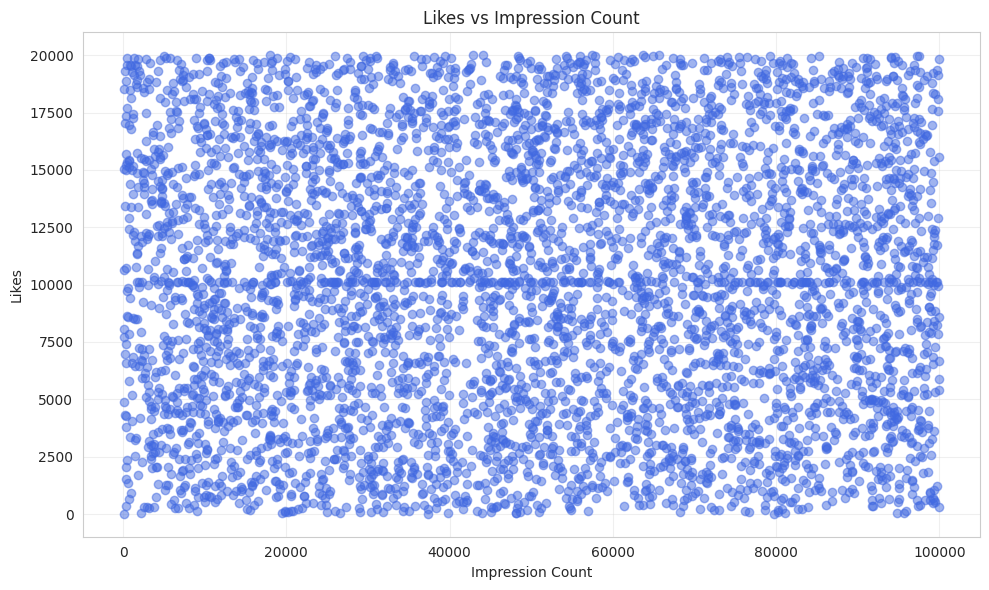

In [84]:
# Plot 1 — Likes vs Impression Count

plt.figure(figsize=(10, 6))

plt.scatter(
    df['impression_count'],
    df['likes'],
    alpha=0.5,
    color='royalblue'
)

plt.title('Likes vs Impression Count')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows the relationship between impressions and likes. A positive relationship would indicate that posts receiving more impressions tend to receive more likes. The degree of scatter indicates that impressions alone do not completely determine the number of likes.

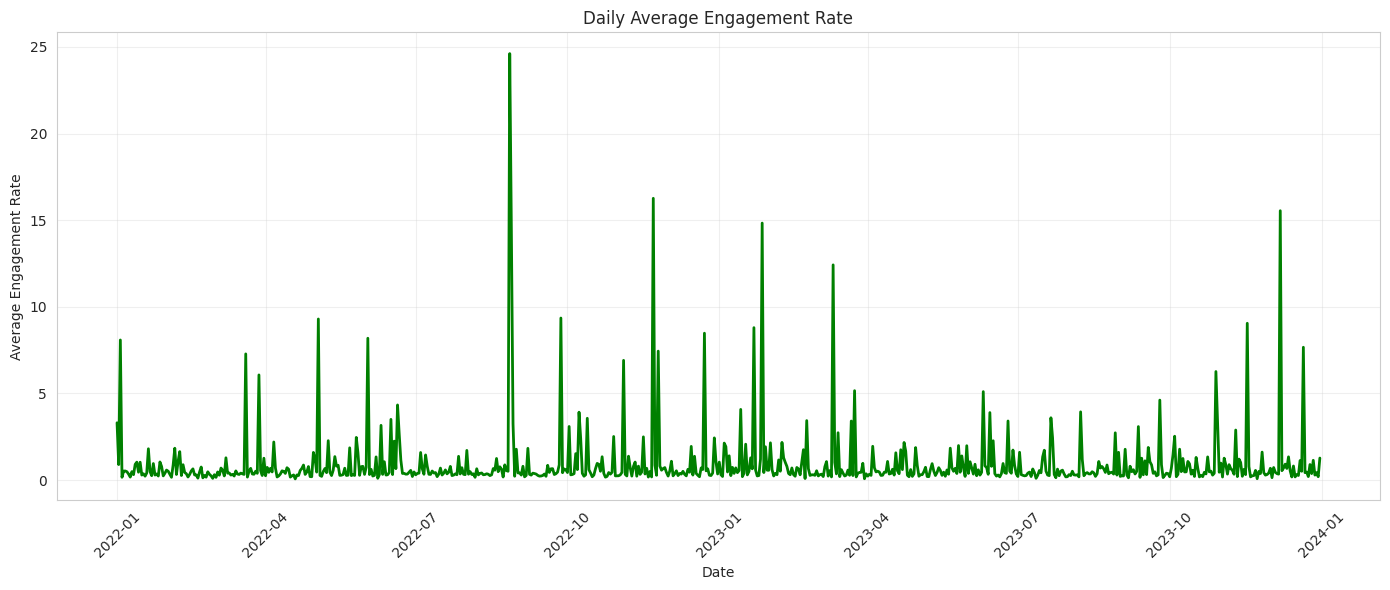

In [85]:
# Plot 2 — Daily engagement trend

daily_engagement = (
    df.groupby('post_date')['engagement_rate']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_engagement['post_date'],
    daily_engagement['engagement_rate'],
    color='green',
    linewidth=2
)

plt.title('Daily Average Engagement Rate')
plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The line chart shows how average engagement rate changes across posting dates. Peaks represent days with relatively stronger engagement, while lower points indicate weaker engagement periods.

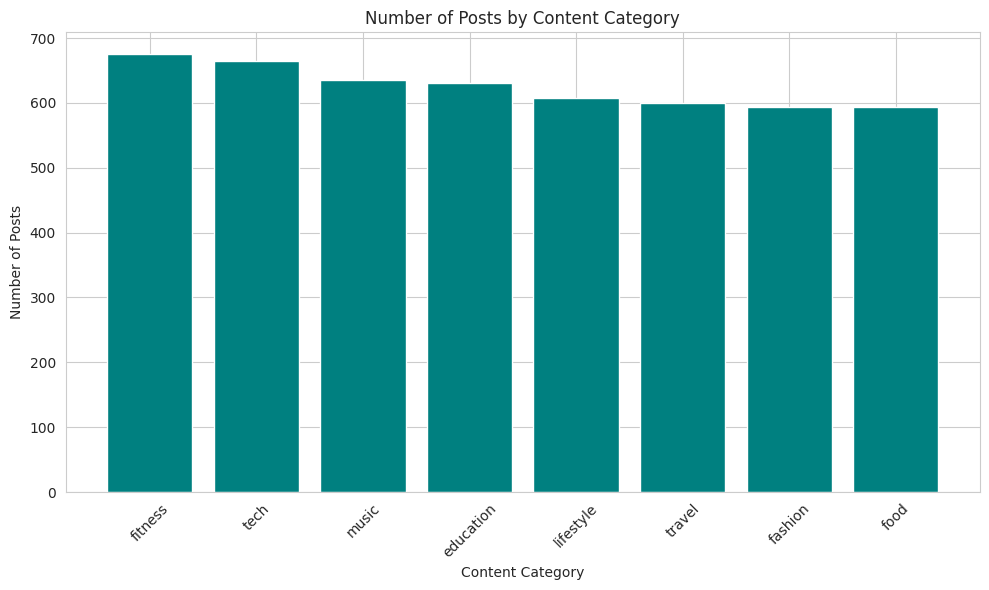

In [86]:
# Plot 3 — Number of posts by category

category_counts = df['post_category'].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values,
    color='teal'
)

plt.title('Number of Posts by Content Category')
plt.xlabel('Content Category')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The bar chart compares the number of posts across content categories. It shows which categories contribute the most and least content to the dataset.

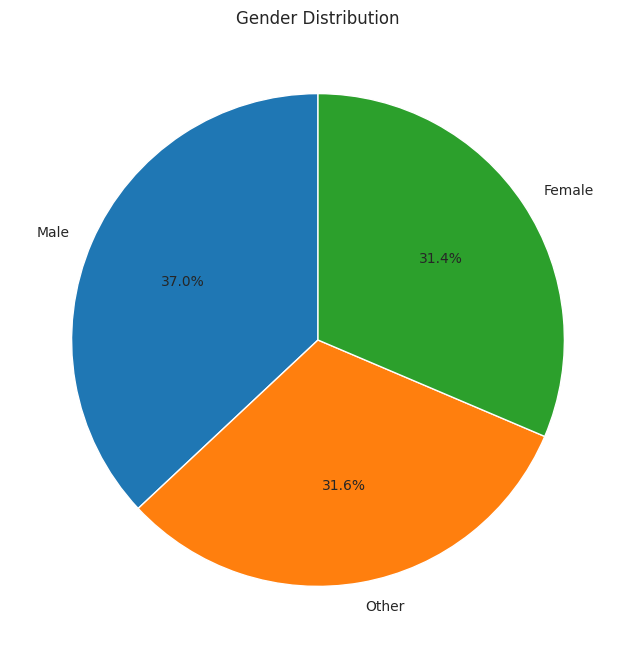

In [87]:
# Plot 4 — Gender distribution

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Gender Distribution')
plt.show()

### Interpretation

The pie chart shows the proportion of users by gender. The distribution indicates how the dataset is composed across the available gender categories.

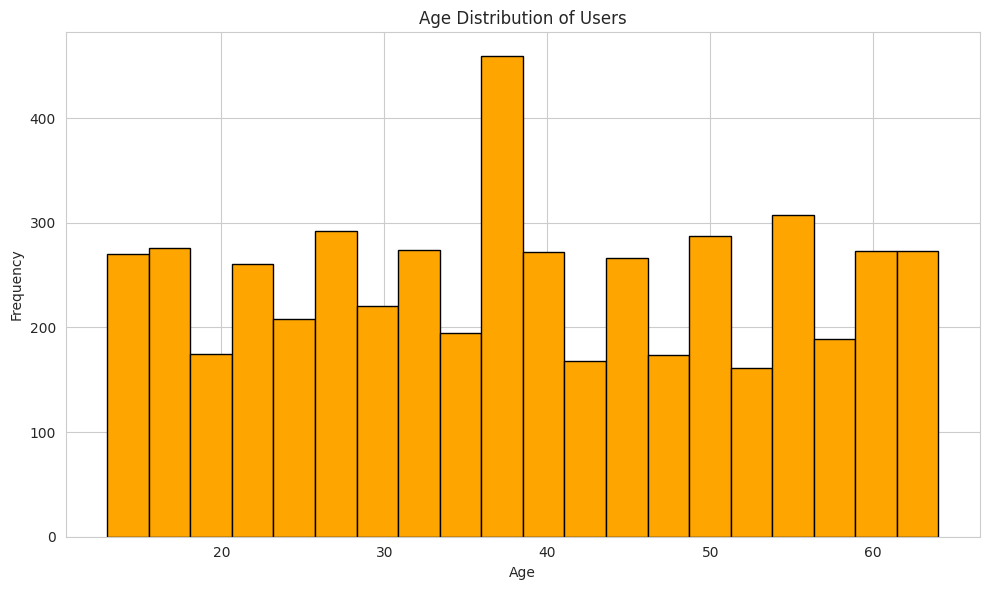

In [88]:
# Plot 5 — Age distribution

plt.figure(figsize=(10, 6))

plt.hist(
    df['age'],
    bins=20,
    color='orange',
    edgecolor='black'
)

plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation

The histogram displays the distribution of user ages. It helps identify the most common age ranges represented in the dataset.

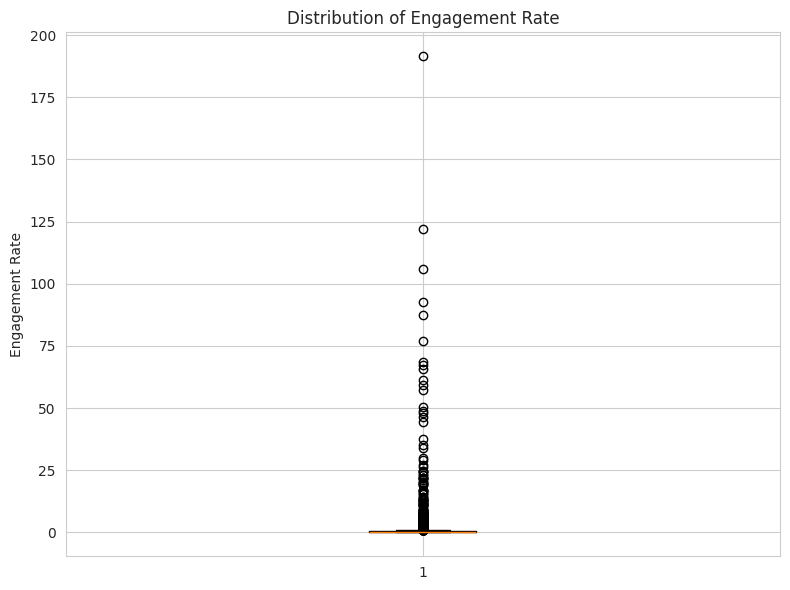

In [89]:
# Plot 6 — Engagement rate box plot

plt.figure(figsize=(8, 6))

plt.boxplot(
    df['engagement_rate'],
    vert=True
)

plt.title('Distribution of Engagement Rate')
plt.ylabel('Engagement Rate')

plt.tight_layout()
plt.show()

### Interpretation

The box plot shows the central distribution and variability of engagement rate. Points beyond the main range may represent unusually high or low engagement observations.

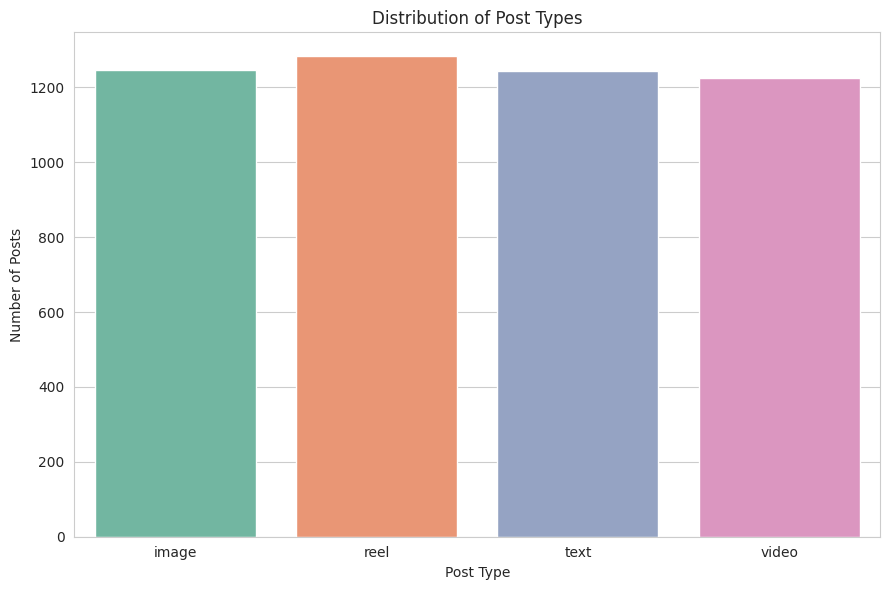

In [90]:
# Plot 7 — Post type count plot

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='post_type',
    hue='post_type',
    palette='Set2',
    legend=False
)

plt.title('Distribution of Post Types')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')

plt.tight_layout()
plt.show()

### Interpretation

The count plot compares the number of posts available for each post type, such as image, reel, text, and video.

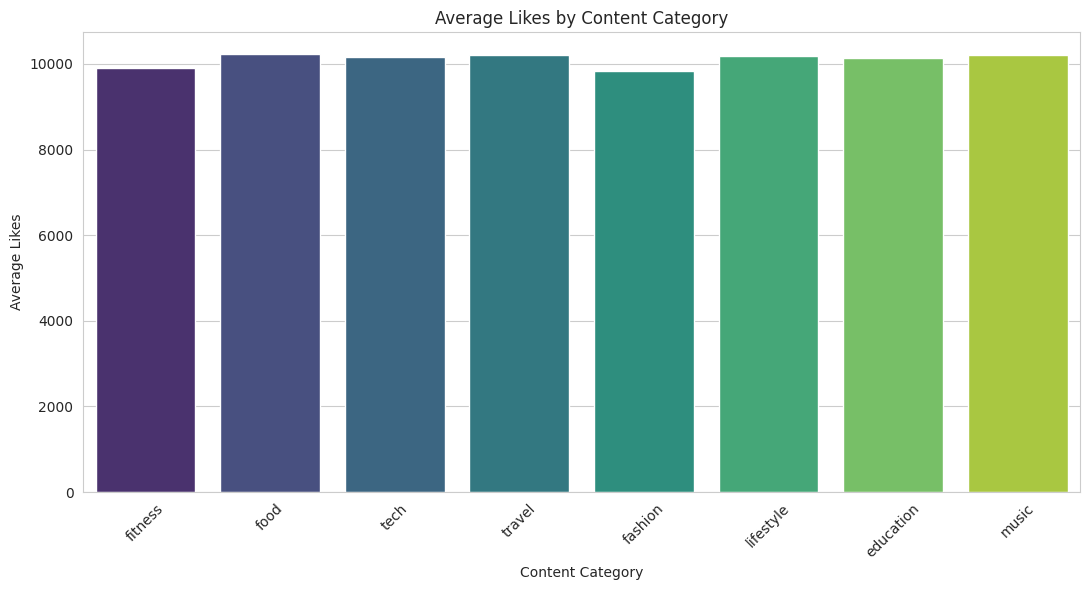

In [91]:
# Plot 8 — Average likes by content category

plt.figure(figsize=(11, 6))

sns.barplot(
    data=df,
    x='post_category',
    y='likes',
    estimator='mean',
    errorbar=None,
    hue='post_category',
    palette='viridis',
    legend=False
)

plt.title('Average Likes by Content Category')
plt.xlabel('Content Category')
plt.ylabel('Average Likes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The bar plot compares the average number of likes received by each content category. The category with the tallest bar has the highest average likes.

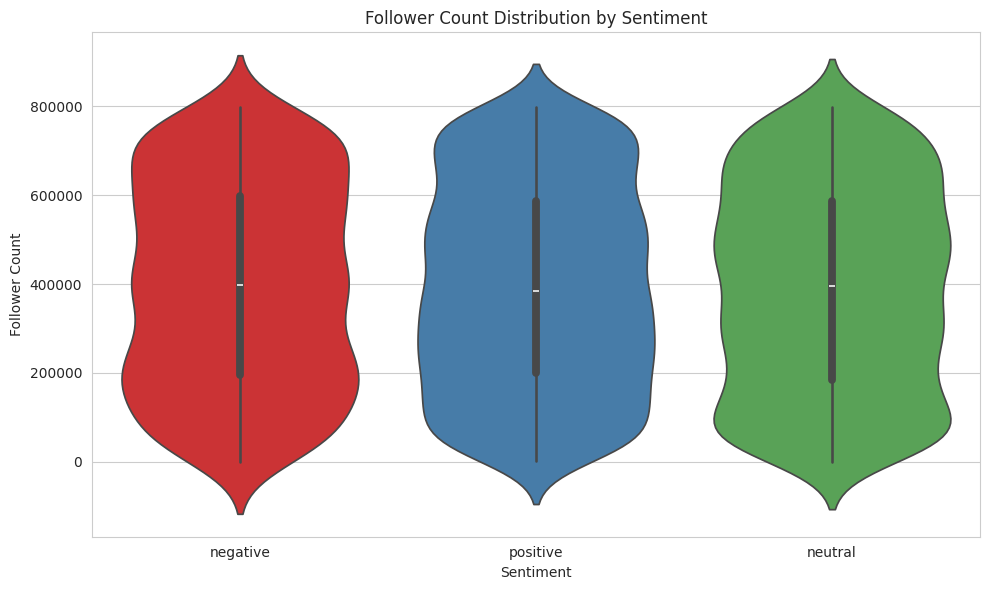

In [92]:
# Plot 9 — Followers by sentiment

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='sentiment',
    y='follower_count',
    hue='sentiment',
    palette='Set1',
    legend=False
)

plt.title('Follower Count Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')

plt.tight_layout()
plt.show()

### Interpretation

The violin plot compares the distribution of follower counts across positive, neutral, and negative sentiment posts. It shows both the spread and concentration of follower counts.

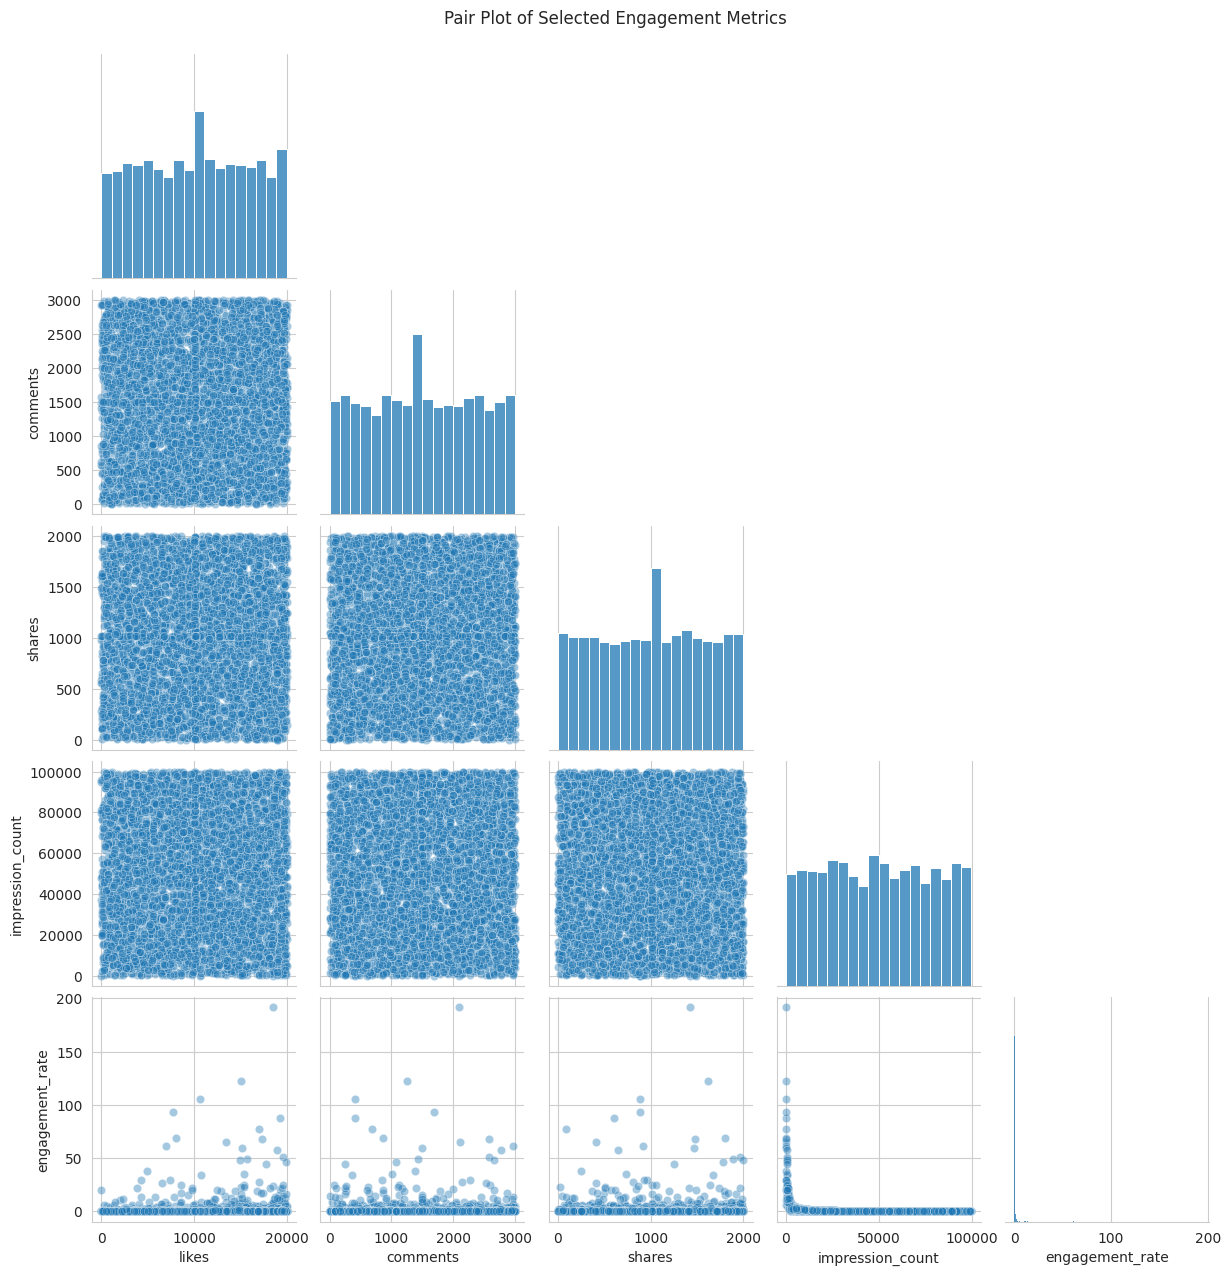

In [93]:
# Plot 10 — Pair plot of selected numeric features

pair_columns = [
    'likes',
    'comments',
    'shares',
    'impression_count',
    'engagement_rate'
]

sns.pairplot(
    df[pair_columns],
    corner=True,
    plot_kws={'alpha': 0.4}
)

plt.suptitle(
    'Pair Plot of Selected Engagement Metrics',
    y=1.02
)

plt.show()

### Interpretation

The pair plot provides a visual overview of relationships among likes, comments, shares, impressions, and engagement rate. Strong upward or downward patterns suggest relationships between variables.

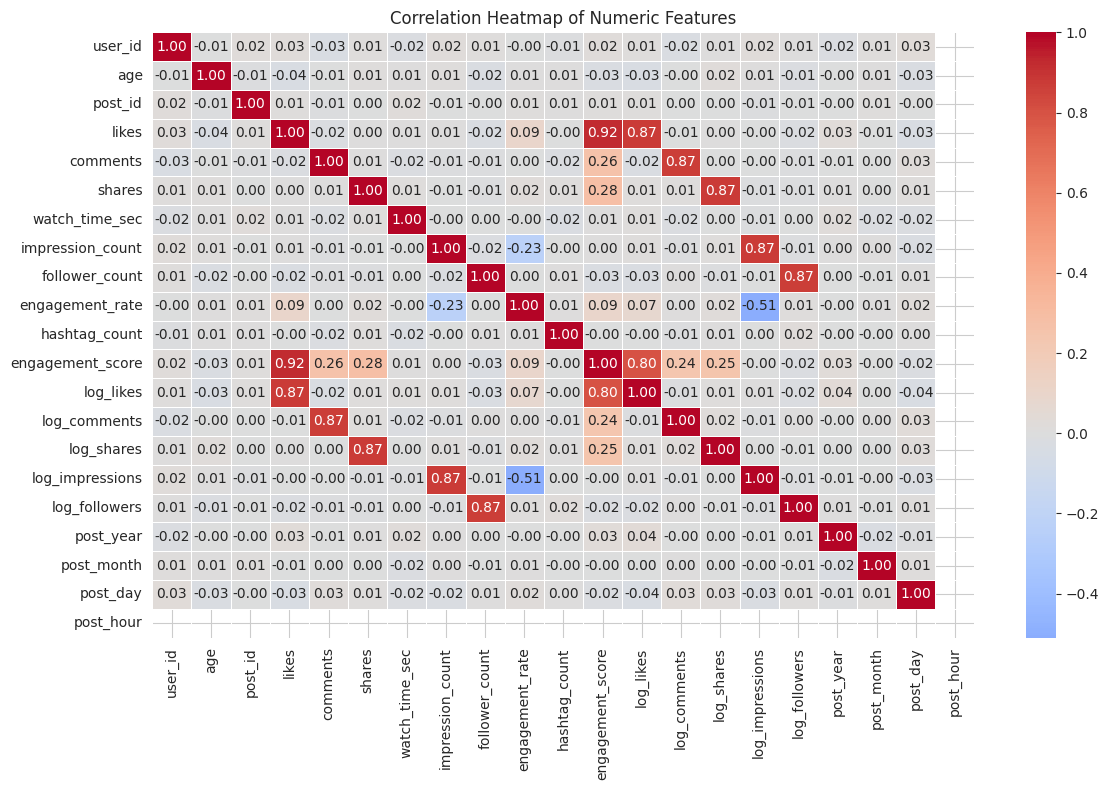

In [94]:
# Plot 11 — Correlation heatmap

plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap shows the strength and direction of relationships between numeric variables. Values closer to +1 indicate strong positive relationships, while values closer to -1 indicate strong negative relationships.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 47.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 51.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 56.2% of the points cannot be plac

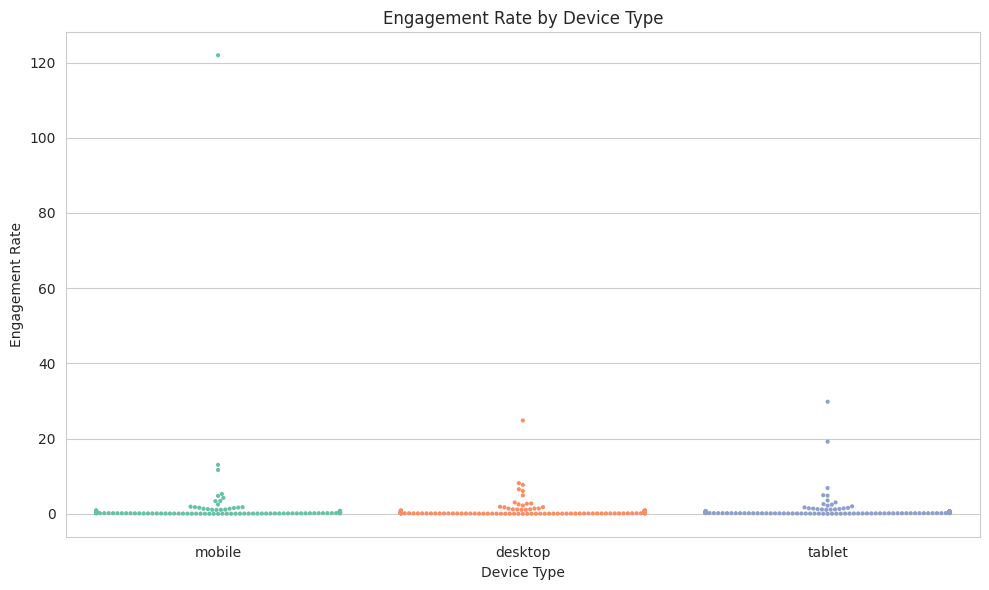

In [95]:
# Plot 12 — Swarm plot of engagement rate by device type

swarm_sample = df.sample(
    n=min(500, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=swarm_sample,
    x='device_type',
    y='engagement_rate',
    hue='device_type',
    palette='Set2',
    legend=False,
    size=3
)

plt.title('Engagement Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')

plt.tight_layout()
plt.show()

### Interpretation

The swarm plot shows the distribution of engagement rates across different device types. It helps identify differences in engagement behavior between mobile, tablet, and desktop users.

In [96]:
# Plot 13 — Interactive daily engagement trend

fig = px.line(
    daily_engagement,
    x='post_date',
    y='engagement_rate',
    title='Interactive Daily Engagement Rate Trend',
    labels={
        'post_date': 'Date',
        'engagement_rate': 'Average Engagement Rate'
    }
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

In [97]:
# Plot 14 — Interactive average likes by category

interactive_category = (
    df.groupby('post_category')['likes']
    .mean()
    .reset_index()
    .sort_values('likes', ascending=False)
)

fig = px.bar(
    interactive_category,
    x='post_category',
    y='likes',
    color='post_category',
    title='Interactive Average Likes by Content Category',
    labels={
        'post_category': 'Content Category',
        'likes': 'Average Likes'
    }
)

fig.show()

In [98]:
# Plot 15 — Interactive engagement scatter plot

fig = px.scatter(
    df,
    x='impression_count',
    y='likes',
    size='comments',
    color='sentiment',
    hover_data=[
        'post_type',
        'post_category',
        'country',
        'device_type',
        'engagement_rate'
    ],
    title='Interactive Impressions vs Likes',
    labels={
        'impression_count': 'Impression Count',
        'likes': 'Likes',
        'comments': 'Comments'
    }
)

fig.show()

# Final Insights and Findings

The following section summarizes the major findings from the exploratory analysis, statistical analysis, and visualizations. The insights are based on content performance, user characteristics, posting behavior, device usage, and sentiment.

In [99]:
# Final insight summary tables

print("=" * 70)
print("1. POST TYPE PERFORMANCE")
print("=" * 70)

print(
    df.groupby('post_type')
      .agg(
          average_engagement_rate=('engagement_rate', 'mean'),
          average_engagement_score=('engagement_score', 'mean'),
          average_likes=('likes', 'mean'),
          average_impressions=('impression_count', 'mean')
      )
      .sort_values('average_engagement_rate', ascending=False)
)


print("\n" + "=" * 70)
print("2. CONTENT CATEGORY PERFORMANCE")
print("=" * 70)

print(
    df.groupby('post_category')
      .agg(
          average_engagement_rate=('engagement_rate', 'mean'),
          average_engagement_score=('engagement_score', 'mean'),
          average_likes=('likes', 'mean'),
          average_impressions=('impression_count', 'mean')
      )
      .sort_values('average_engagement_rate', ascending=False)
)


print("\n" + "=" * 70)
print("3. COUNTRY PERFORMANCE")
print("=" * 70)

print(
    df.groupby('country')
      .agg(
          average_engagement_rate=('engagement_rate', 'mean'),
          average_likes=('likes', 'mean'),
          average_impressions=('impression_count', 'mean')
      )
      .sort_values('average_engagement_rate', ascending=False)
)


print("\n" + "=" * 70)
print("4. VERIFIED VS NON-VERIFIED")
print("=" * 70)

print(
    df.groupby('is_verified')
      .agg(
          average_engagement_rate=('engagement_rate', 'mean'),
          average_likes=('likes', 'mean'),
          average_impressions=('impression_count', 'mean'),
          average_watch_time=('watch_time_sec', 'mean')
      )
)


print("\n" + "=" * 70)
print("5. TIME OF DAY PERFORMANCE")
print("=" * 70)

print(
    df.groupby('time_of_day')
      .agg(
          average_impressions=('impression_count', 'mean'),
          average_engagement_rate=('engagement_rate', 'mean'),
          average_watch_time=('watch_time_sec', 'mean')
      )
      .sort_values('average_impressions', ascending=False)
)


print("\n" + "=" * 70)
print("6. DEVICE PERFORMANCE")
print("=" * 70)

print(
    df.groupby('device_type')
      .agg(
          average_watch_time=('watch_time_sec', 'mean'),
          average_engagement_rate=('engagement_rate', 'mean'),
          average_impressions=('impression_count', 'mean')
      )
      .sort_values('average_watch_time', ascending=False)
)


print("\n" + "=" * 70)
print("7. SENTIMENT PERFORMANCE")
print("=" * 70)

print(
    df.groupby('sentiment')
      .agg(
          average_engagement_rate=('engagement_rate', 'mean'),
          average_engagement_score=('engagement_score', 'mean'),
          average_likes=('likes', 'mean'),
          average_comments=('comments', 'mean'),
          average_shares=('shares', 'mean'),
          average_impressions=('impression_count', 'mean')
      )
      .sort_values('average_engagement_rate', ascending=False)
)


1. POST TYPE PERFORMANCE
           average_engagement_rate  average_engagement_score  average_likes  \
post_type                                                                     
video                     1.122365              16137.422857   10188.600000   
text                      1.064549              16140.328916   10100.148193   
image                     0.895646              16213.205293   10104.865277   
reel                      0.783047              15992.302806   10037.802416   

           average_impressions  
post_type                       
video             49862.014694  
text              49987.218474  
image             49727.421812  
reel              50462.598597  

2. CONTENT CATEGORY PERFORMANCE
               average_engagement_rate  average_engagement_score  \
post_category                                                      
food                          1.358628              16255.679595   
tech                          1.160475              16210.778947 

In [100]:
# Check posting hours and time-of-day categories

print("Posting hour distribution:")
print(df['post_hour'].value_counts().sort_index())

print("\nTime-of-day distribution:")
print(df['time_of_day'].value_counts())

Posting hour distribution:
post_hour
0    5000
Name: count, dtype: int64

Time-of-day distribution:
time_of_day
Night    5000
Name: count, dtype: int64


# Final Insights

## 1. Content Performance

Video posts achieved the highest average engagement rate at approximately 1.12, followed by text posts at 1.06. This indicates that video content was the strongest-performing post type based on engagement rate.

Among content categories, food had the highest average engagement rate at approximately 1.36, followed by technology at approximately 1.16. Therefore, food content appears to be the best-performing content category in this dataset.

Brazil recorded the highest average engagement rate among the countries analyzed, at approximately 1.54. Australia ranked second at approximately 1.32. The USA had the lowest average engagement rate at approximately 0.58.


## 2. User Trends

Verified accounts had a higher average engagement rate than non-verified accounts. Verified accounts achieved an average engagement rate of approximately 1.05 compared with 0.95 for non-verified accounts.

Verified accounts also had higher average impressions and watch time. However, non-verified accounts had slightly higher average likes. This suggests that verification may be associated with greater reach and engagement efficiency, although it does not necessarily result in more likes per post.

Age-related engagement was further examined using age groups and correlation analysis. The results can be used to identify whether particular age groups demonstrate higher engagement rates.


## 3. Behavioral Insights

Mobile users had the highest average watch time at approximately 4,087.83 seconds, compared with approximately 3,979.74 seconds for tablet users and 3,974.79 seconds for desktop users.

Mobile users also had the highest average engagement rate at approximately 1.12. This suggests that mobile devices are particularly important for social media engagement in this dataset.

The posting-time analysis could not identify a reliable best time of day because all 5,000 records have a posting hour of 0 (midnight). Therefore, there is insufficient variation in the available time information to determine which time of day produces the highest impressions.


## 4. Sentiment Analysis

Negative sentiment posts achieved the highest average engagement rate at approximately 1.04, followed by neutral posts at approximately 0.99 and positive posts at approximately 0.92.

Negative sentiment posts also had the highest average likes and shares. Neutral posts had the highest average comments, while positive posts had a lower average engagement rate.

These findings suggest that negative or controversial content may generate relatively strong interaction in this dataset. However, higher engagement does not necessarily mean that negative content is more valuable or desirable from a business or brand perspective.


## Overall Finding

Overall, video posts and food-related content demonstrated strong engagement performance. Brazil was the highest-performing country by average engagement rate. Verified accounts showed higher engagement rates than non-verified accounts, while mobile users recorded the highest watch time and engagement rate. Negative sentiment posts generated the highest average engagement rate. The available posting-time data did not contain sufficient variation to determine the best time of day for impressions.
